In [2]:
import zipfile
import io
import os
import numpy as np
import numpy.random as random
import scipy as sp
import pandas as pd
from pandas import Series, DataFrame

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
%matplotlib inline

# Display up to three decimal places
%precision 3

'%.3f'

Input Data

In [24]:
orders = pd.read_csv("../data/orders.csv")
products = pd.read_csv("../data/products.csv")
returns = pd.read_csv("../data/returns.csv")
shipments = pd.read_csv("../data/shipments.csv")
order_items = pd.read_csv("../data/order_items.csv")
reviews = pd.read_csv("../data/reviews.csv")
geography = pd.read_csv("../data/geography.csv")
inventory = pd.read_csv("../data/inventory.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8\3110772039.py:5: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("../data/order_items.csv")


In [4]:
dfs = {
    'orders': orders,
    'products': products,
    'returns': returns,
    'shipments': shipments,
    'order_items': order_items,
    'reviews': reviews,
    'geography': geography
}

for name, data in dfs.items():
    print(f'The {name} table has {data.shape[0]} rows and {data.shape[1]} columns')

The orders table has 646945 rows and 8 columns
The products table has 2412 rows and 8 columns
The returns table has 39939 rows and 7 columns
The shipments table has 566067 rows and 4 columns
The order_items table has 714669 rows and 7 columns
The reviews table has 113551 rows and 7 columns
The geography table has 39948 rows and 4 columns


In [5]:
for name, data in dfs.items():
    print(f'Missing values of {name} table \n {data.isnull().sum()}')

Missing values of orders table 
 order_id          0
order_date        0
customer_id       0
zip               0
order_status      0
payment_method    0
device_type       0
order_source      0
dtype: int64
Missing values of products table 
 product_id      0
product_name    0
category        0
segment         0
size            0
color           0
price           0
cogs            0
dtype: int64
Missing values of returns table 
 return_id          0
order_id           0
product_id         0
return_date        0
return_reason      0
return_quantity    0
refund_amount      0
dtype: int64
Missing values of shipments table 
 order_id         0
ship_date        0
delivery_date    0
shipping_fee     0
dtype: int64
Missing values of order_items table 
 order_id                0
product_id              0
quantity                0
unit_price              0
discount_amount         0
promo_id           438353
promo_id_2         714463
dtype: int64
Missing values of reviews table 
 review_id       

In [ ]:
orders.head(10)

0


In [ ]:
order_items.head(10)

0         False
1         False
2         False
3         False
4         False
          ...  
714664    False
714665    False
714666    False
714667    False
714668    False
Length: 714669, dtype: bool


Reviews Overall:
+ Chủ yếu là 5 sao
+ No fucking idea

In [8]:
reviews.head(10)

,review_id,order_id,product_id,customer_id,review_date,rating,review_title
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall
5,REV-0000008,20,2241,42962,2012-08-12,5,Great quality
6,REV-0000009,23,1041,12213,2012-07-19,5,Very satisfied
7,REV-0000010,24,671,13426,2012-08-09,4,Solid choice
8,REV-0000011,28,396,9473,2012-07-27,5,Very satisfied
9,REV-0000012,49,671,39696,2012-07-17,5,Highly recommend


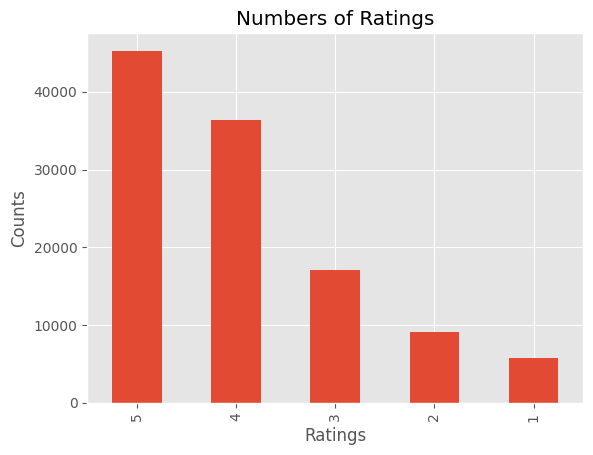

In [9]:
rating = reviews['rating'].value_counts().plot(kind = 'bar', title='Numbers of Ratings')
rating.set_xlabel('Ratings')
rating.set_ylabel('Counts')
plt.show()

In [10]:
bad_reviews = reviews[reviews['rating'] <= 3].copy().sort_values(by='rating')
bad_reviews.groupby('rating')['review_title'].value_counts()

rating  review_title           
1       Would not recommend        1460
        Poor quality               1443
        Very disappointed          1442
        Not as described           1427
2       Some issues                3037
        Would not reorder          3034
        Below expectations         3024
3       Mixed feelings             5706
        Average product            5656
        Decent, nothing special    5654
Name: count, dtype: int64

Returns Overall:
+ Lý do wrong size là lý do khiến cho khách hàng phải trả lại hàng nhiều nhất (cũng là có số tiền refund lớn nhất). 
+ 2 sản phẩm bị returned vì wrong_size nhiều nhất là HanoiStreet và RP-80 HanoiStreet RP-79            


In [ ]:
returns.sort_values(by='order_id')

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76
...,...,...,...,...,...,...,...
39934,RET-051470,832867,653,2022-12-27,wrong_size,3,24741.62
39935,RET-051471,832890,792,2022-12-30,late_delivery,1,560.50
39936,RET-051481,833005,449,2022-12-31,defective,1,10002.55
39937,RET-051494,833234,1085,2022-12-28,wrong_size,1,815.57


In [15]:
returns_rate = returns.shape[0]/orders.shape[0]
print(f'The overall return rate is {returns_rate*100}%')

The overall return rate is 6.173476879796582%


In [12]:
order_returns = pd.merge(order_items, returns, on=['order_id', 'product_id'], how='inner')
order_returns.head(10)

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,return_id,return_date,return_reason,return_quantity,refund_amount
0,2,609,7,10166.25,0.0,NaN,NaN,RET-000001,2012-07-25,late_delivery,6,52458.01
1,32,1862,6,2599.04,0.0,NaN,NaN,RET-000002,2012-07-16,wrong_size,2,5141.37
2,35,2359,2,5362.22,0.0,NaN,NaN,RET-000003,2012-07-16,wrong_size,1,5315.95
3,47,1449,6,1759.59,0.0,NaN,NaN,RET-000004,2012-07-11,wrong_size,4,6493.75
4,47,1450,3,1809.15,0.0,NaN,NaN,RET-000005,2012-07-25,wrong_size,1,1740.76
5,59,671,2,11173.11,0.0,NaN,NaN,RET-000006,2012-07-19,defective,1,10086.33
6,67,604,2,6208.65,0.0,NaN,NaN,RET-000007,2012-07-16,wrong_size,1,5713.22
7,102,467,1,11012.40,0.0,NaN,NaN,RET-000008,2012-07-17,defective,1,9724.09
8,108,635,7,10143.99,0.0,NaN,NaN,RET-000010,2012-07-30,wrong_size,5,43387.54
9,132,103,3,10169.15,0.0,NaN,NaN,RET-000012,2012-07-29,changed_mind,2,19200.35


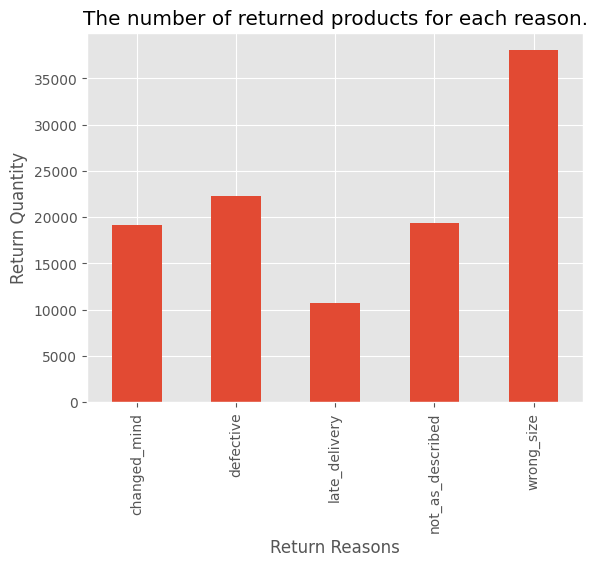

In [47]:
returns = returns[['product_id','return_reason','return_quantity','refund_amount']]
ax = returns.groupby('return_reason').sum()['return_quantity'].plot(kind = 'bar',title ='The number of returned products for each reason.')
ax.set_xlabel("Return Reasons")
ax.set_ylabel("Return Quantity")
plt.show()

In [19]:
products.head(10)
products.shape
products_returns = pd.merge(products,returns,how = 'inner')

           product_name  return_quantity
146   HanoiStreet RP-80             1732
145   HanoiStreet RP-79             1577
691    SaigonFlex UC-69             1169
1138   VietMotion UE-06             1139
801    SaigonFlex UM-92             1129
221   HanoiStreet UE-36             1121
884       UrbanVN UE-05             1089
437     MekongFit UE-18             1079
729    SaigonFlex UM-01             1052
228   HanoiStreet UM-10              996


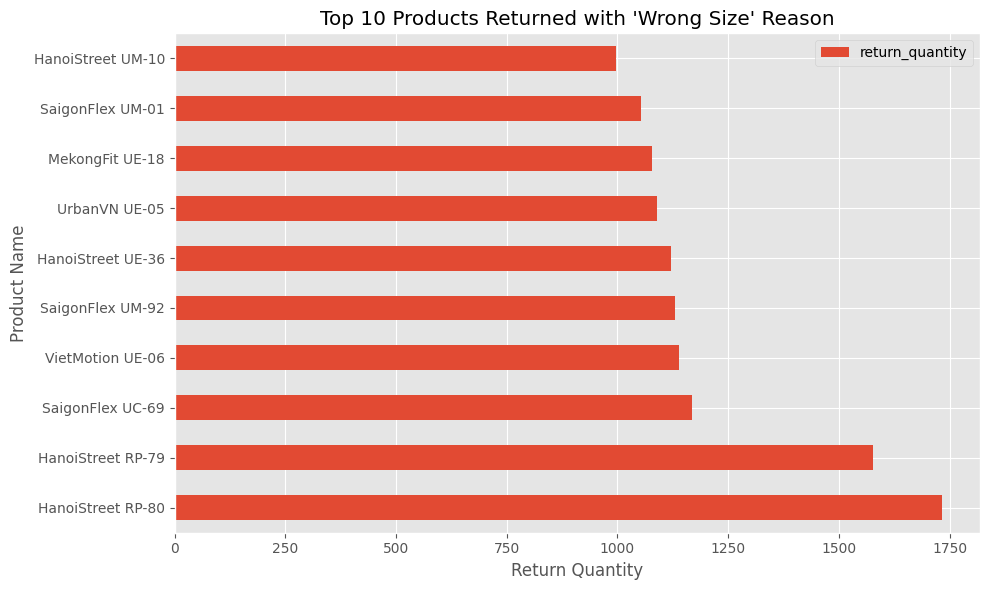

In [48]:
# Find which product is returned the most with "wrong_size" reason
product_wrong_size = products_returns.groupby('product_name', as_index=False)['return_quantity'].sum()
product_wrong_size = product_wrong_size.sort_values(by='return_quantity', ascending=False)
print(product_wrong_size.head(10))

# Or visualize it
ax = product_wrong_size.head(10).plot(x='product_name', y='return_quantity', kind='barh', figsize=(10, 6))
ax.set_xlabel("Return Quantity")
ax.set_ylabel("Product Name")
ax.set_title("Top 10 Products Returned with 'Wrong Size' Reason")
plt.tight_layout()
plt.show()

In [24]:
order_returns.head(10)

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,return_id,return_date,return_reason,return_quantity,refund_amount
0,2,609,7,10166.25,0.0,NaN,NaN,RET-000001,2012-07-25,late_delivery,6,52458.01
1,32,1862,6,2599.04,0.0,NaN,NaN,RET-000002,2012-07-16,wrong_size,2,5141.37
2,35,2359,2,5362.22,0.0,NaN,NaN,RET-000003,2012-07-16,wrong_size,1,5315.95
3,47,1449,6,1759.59,0.0,NaN,NaN,RET-000004,2012-07-11,wrong_size,4,6493.75
4,47,1450,3,1809.15,0.0,NaN,NaN,RET-000005,2012-07-25,wrong_size,1,1740.76
5,59,671,2,11173.11,0.0,NaN,NaN,RET-000006,2012-07-19,defective,1,10086.33
6,67,604,2,6208.65,0.0,NaN,NaN,RET-000007,2012-07-16,wrong_size,1,5713.22
7,102,467,1,11012.40,0.0,NaN,NaN,RET-000008,2012-07-17,defective,1,9724.09
8,108,635,7,10143.99,0.0,NaN,NaN,RET-000010,2012-07-30,wrong_size,5,43387.54
9,132,103,3,10169.15,0.0,NaN,NaN,RET-000012,2012-07-29,changed_mind,2,19200.35


In [63]:
shipments.head(10)

,order_id,ship_date,delivery_date,shipping_fee
0,1,2012-07-07,2012-07-11,1.37
1,2,2012-07-06,2012-07-10,2.60
2,3,2012-07-04,2012-07-07,2.38
3,4,2012-07-05,2012-07-11,2.49
4,6,2012-07-09,2012-07-16,25.79
5,7,2012-07-06,2012-07-12,1.31
6,8,2012-07-06,2012-07-11,0.43
7,9,2012-07-07,2012-07-13,0.18
8,10,2012-07-07,2012-07-13,0.86
9,13,2012-07-09,2012-07-12,2.44


In [ ]:
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])
shipments['delivery_time'] = shipments['delivery_date'] - shipments['ship_date']
shipments['delivery_time'].mean()

Timedelta('4 days 11:58:51.697131')